# Automatic differentiation from the ground up

*Foundations for the GT4Py AD series. `nb01` and `nb02` assume everything here.*

Weather and climate codes need derivatives for four reasons: variational data
assimilation (4D-Var minimises a cost function over millions of control variables),
sensitivity and observation targeting, gradient-based parameter calibration, and —
lately — training neural parameterisations through a differentiable solver.

All four need the same object: the derivative of a **program**. Not of a formula you
can hand to a symbolic algebra system, but of a few hundred thousand lines that
branch, loop, and call each other. Automatic differentiation is how you get it, and
the point of this notebook is that it is not magic. By section 8 you will have
written both modes yourself in about eighty lines.

The route is the classical one: differentiate something by hand, watch finite
differences fail, discover forward mode by accident, notice that the chain rule is a
matrix product, and read reverse mode straight off the associativity of matrix
multiplication.

**Contents**

1. One function, differentiated by hand
2. Finite differences, and why they disappoint
3. The complex-step trick
4. Dual numbers: forward mode from scratch
5. Vectors: the Jacobian
6. The chain rule is a matrix product — and that is all of AD
7. Cost: why the adjoint exists
8. Reverse mode from scratch: the tape
9. What JAX gives you, and the NWP dictionary
10. Verifying a gradient: the two tests
11. Where it gets hard
12. From three variables to a model

In [1]:
import functools
import math
import time
from collections import defaultdict

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

BLUE, ORANGE, MAGENTA = "#1f6fb4", "#d1590a", "#b03a6f"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print(f"jax {jax.__version__}, float64 = {jax.config.jax_enable_x64}")

jax 0.6.2, float64 = True


## 1. One function, differentiated by hand

Saturation vapour pressure over water — the Magnus form, with the Alduchov–Eskridge
(1996) coefficients, `T` in °C and the result in Pa:

$$e_s(T) = A \exp\!\left(\frac{B\,T}{T + C}\right), \qquad A = 610.94,\; B = 17.625,\; C = 243.04$$

Small enough to differentiate on paper. Writing $u = BT/(T+C)$,

$$\frac{du}{dT} = \frac{B(T+C) - BT}{(T+C)^2} = \frac{BC}{(T+C)^2},
\qquad\text{so}\qquad
\frac{de_s}{dT} = e_s(T)\,\frac{BC}{(T+C)^2}.$$

That closed form is the reference every other method in this notebook is measured
against.

In [2]:
A, B, C = 610.94, 17.625, 243.04


def es(T):
    return A * math.exp(B * T / (T + C))


def des_dT_analytic(T):
    return es(T) * B * C / (T + C) ** 2


T0 = 15.0
exact = des_dT_analytic(T0)
print(f"e_s({T0} C)      = {es(T0):.6f} Pa")
print(f"de_s/dT at {T0} C = {exact:.15f} Pa/K")

e_s(15.0 C)      = 1701.982815 Pa
de_s/dT at 15.0 C = 109.493411247247650 Pa/K


Notice what "by hand" cost us: we had to *look at the expression*. For a real model
that route is closed — not because the calculus is hard, but because there are a
million lines of it and it changes every week.

## 2. Finite differences, and why they disappoint

The obvious fallback needs no knowledge of the function at all, only the ability to
call it:

$$\text{forward:}\quad \frac{f(x+h) - f(x)}{h} = f'(x) + \tfrac{h}{2}f''(x) + O(h^2)$$

$$\text{central:}\quad \frac{f(x+h) - f(x-h)}{2h} = f'(x) + \tfrac{h^2}{6}f'''(x) + O(h^4)$$

Both are wrong by a **truncation** error that shrinks with `h`. So take `h` small.

The trouble is that `f(x+h)` and `f(x)` agree in their leading digits, and subtracting
them throws those digits away — **subtractive cancellation**. In double precision the
subtraction carries an absolute error of about $\varepsilon|f|$ with
$\varepsilon \approx 2.2\times10^{-16}$ — and since both evaluations contribute,
dividing by `h` amplifies it to $2\varepsilon|f|/h$. Total error:

$$E_{\text{fwd}}(h) \approx \underbrace{\tfrac{h}{2}|f''|}_{\text{truncation}} + \underbrace{\tfrac{2\varepsilon|f|}{h}}_{\text{roundoff}}$$

which is minimised at $h_{\text{opt}} = 2\sqrt{\varepsilon|f|/|f''|}$, where the error is
$2\sqrt{\varepsilon|f||f''|}$. Dropping the function-dependent factors, that is
$h \sim \sqrt{\varepsilon}$ and an error of order $\sqrt{\varepsilon}$: **you lose half
your significant digits, and no choice of `h` avoids it.** Central differences do
better — $h^3 = 3\varepsilon|f|/|f'''|$, error about $\varepsilon^{2/3}$ — but still lose
a third.

The dropped factors are not small. For $e_s$ they move the optimum by a factor of
about 30, so the measured optimum below sits near $5\times10^{-7}$ rather than
$\sqrt{\varepsilon} \approx 1.5\times10^{-8}$. The *scaling* is what to remember, not
the bare number.

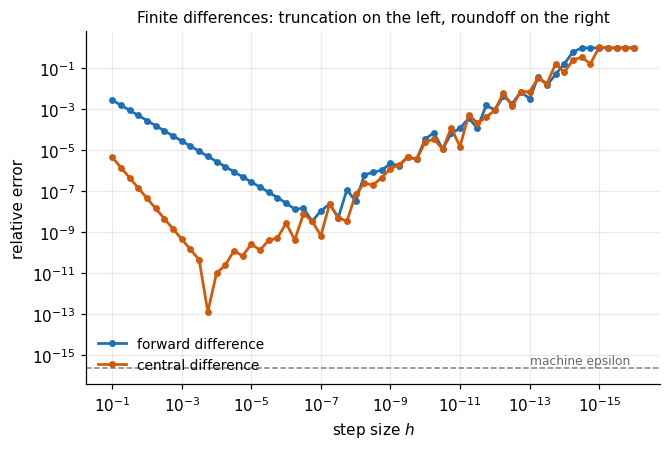

forward : predicted h_opt = 4.94e-07, error there ~ 1.39e-08   (sqrt(eps) = 1.49e-08)
central : predicted h_opt ~ 1.6e-04, error there ~ 1.72e-11   (eps^(2/3) = 3.67e-11)

the single best grid point is 1.29e-13, an accidental cancellation --
it moves by two orders of magnitude if you change the number of sample points.


In [3]:
hs = np.logspace(-1, -16, 61)
err_fwd, err_ctr = [], []
for h in hs:
    err_fwd.append(abs((es(T0 + h) - es(T0)) / h - exact) / abs(exact))
    err_ctr.append(abs((es(T0 + h) - es(T0 - h)) / (2 * h) - exact) / abs(exact))

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(hs, err_fwd, "o-", color=BLUE, lw=1.8, ms=3.5, label="forward difference")
ax.loglog(hs, err_ctr, "o-", color=ORANGE, lw=1.8, ms=3.5, label="central difference")
ax.axhline(np.finfo(float).eps, color="0.5", ls="--", lw=1)
ax.annotate("machine epsilon", (1e-13, np.finfo(float).eps * 1.6), color="0.4", fontsize=8)
ax.invert_xaxis()
ax.set_xlabel("step size $h$")
ax.set_ylabel("relative error")
ax.set_title("Finite differences: truncation on the left, roundoff on the right", fontsize=10)
ax.legend(frameon=False, fontsize=9, loc="lower left")
fig.tight_layout()
plt.show()

# The pointwise minimum of a cancellation-noise curve is a lucky grid point, not a
# property of the method -- quote the theory's optimum and a local median instead.
eps = np.finfo(float).eps
f0 = es(T0)
f2 = f0 * (B * C / (T0 + C) ** 2) ** 2 - 2 * f0 * B * C / (T0 + C) ** 3
h_fwd = 2 * math.sqrt(eps * abs(f0) / abs(f2))


def local_median(err, h_star):
    sel = [e for e, h in zip(err, hs) if h_star / 3 < h < h_star * 3]
    return float(np.median(sel))


print(f"forward : predicted h_opt = {h_fwd:.2e}, error there ~ {local_median(err_fwd, h_fwd):.2e}"
      f"   (sqrt(eps) = {math.sqrt(eps):.2e})")
print(f"central : predicted h_opt ~ 1.6e-04, error there ~ {local_median(err_ctr, 1.6e-4):.2e}"
      f"   (eps^(2/3) = {eps**(2/3):.2e})")
print(f"\nthe single best grid point is {min(err_ctr):.2e}, an accidental cancellation --")
print("it moves by two orders of magnitude if you change the number of sample points.")

The V is the whole story: accuracy improves as `h` falls until cancellation takes
over, then collapses. And the best point is not something you can find without
already knowing the answer.

There is a second objection, and for our purposes it is the fatal one. **Cost.** A
gradient in $n$ dimensions needs $n+1$ evaluations (forward) or $2n$ (central). For a
4D-Var control vector with $n \sim 10^7$, one gradient would cost ten million model
runs. Finite differences are not a slow way to do 4D-Var; they are not a way to do
4D-Var.

## 3. The complex-step trick

Before the real machinery, a detour that makes the idea visible. Expand `f` at a
*complex* perturbation, assuming `f` is analytic:

$$f(x + ih) = f(x) + ih f'(x) - \tfrac{h^2}{2}f''(x) - i\tfrac{h^3}{6}f'''(x) + \dots$$

Take the imaginary part and divide by `h`:

$$\frac{\operatorname{Im} f(x+ih)}{h} = f'(x) - \tfrac{h^2}{6}f'''(x) + O(h^4)$$

Second-order accurate — and there is **no subtraction of nearly equal numbers**. So
`h` can be made absurdly small and the truncation term simply vanishes.

In [4]:
def es_complex(T):
    return A * np.exp(B * T / (T + C))


for h in (1e-4, 1e-20, 1e-200):
    cs = es_complex(complex(T0, h)).imag / h
    print(f"h = {h:6.0e}   d/dT = {cs:.15f}   relative error = {abs(cs - exact) / exact:.2e}")

h =  1e-04   d/dT = 109.493411246748906   relative error = 4.56e-12
h =  1e-20   d/dT = 109.493411247247664   relative error = 1.30e-16
h = 1e-200   d/dT = 109.493411247247636   relative error = 1.30e-16


Exact to roundoff, at any step size, and it is genuinely used in practice — but it
does not rescue us. Two reasons, and the second is the one that matters.

It needs an analytic function. Naively, `abs`, `max` and any comparison break it,
though in practice these are redefined to act on the real part (Martins, Sturdza &
Alonso 2003), after which such code works and returns a one-sided derivative at a
kink — exactly as AD does, see section 11. So this limitation is real but repairable.

The fatal one is cost: complex step gives **one directional derivative per run**, so a
gradient in $n$ dimensions still needs $n$ passes, each 2–4× the cost of the original.
It does not answer section 2's objection at all.

Still, look at what actually happened. We carried a **second component** alongside
every intermediate value, and the rules of complex arithmetic propagated it correctly
through every operation. The step size was irrelevant because that component was
never a difference in the first place.

That is the idea. All that remains is to pick better rules than $i^2 = -1$.

## 4. Dual numbers: forward mode from scratch

Replace the imaginary unit with a symbol $\epsilon$ satisfying

$$\epsilon^2 = 0, \qquad \epsilon \neq 0.$$

A **dual number** is $a + b\epsilon$. Multiplication drops the $\epsilon^2$ term:

$$(a + b\epsilon)(c + d\epsilon) = ac + (ad + bc)\epsilon$$

and the $\epsilon$ component is exactly the product rule. In general, for `f`
differentiable at $a$, the Taylor series terminates after the first-order term:

$$f(a + b\epsilon) = f(a) + b\,f'(a)\,\epsilon$$

So: **evaluate the program on dual numbers, seed the input with
$\epsilon$-component 1, and read the derivative off the output.** No step size, no
cancellation, no truncation — it is the exact derivative of the code as written.

In [5]:
class Dual:
    '''a + b*eps with eps**2 = 0.'''

    def __init__(self, a, b=0.0):
        self.a, self.b = a, b

    @staticmethod
    def _lift(o):
        return o if isinstance(o, Dual) else Dual(o)

    def __add__(self, o):
        o = Dual._lift(o)
        return Dual(self.a + o.a, self.b + o.b)

    def __sub__(self, o):
        o = Dual._lift(o)
        return Dual(self.a - o.a, self.b - o.b)

    def __mul__(self, o):
        o = Dual._lift(o)
        return Dual(self.a * o.a, self.a * o.b + self.b * o.a)          # product rule

    def __truediv__(self, o):
        o = Dual._lift(o)
        return Dual(self.a / o.a, (self.b * o.a - self.a * o.b) / o.a**2)  # quotient rule

    __radd__ = __add__
    __rmul__ = __mul__

    def __rsub__(self, o):
        return Dual._lift(o) - self

    def __rtruediv__(self, o):
        return Dual._lift(o) / self

    def exp(self):
        e = math.exp(self.a)
        return Dual(e, self.b * e)                                      # chain rule

    def __repr__(self):
        return f"{self.a} + {self.b}*eps"


def es_generic(T, exp):
    '''The Tetens formula, written once, evaluated on floats or on Duals.'''
    return A * exp(B * T / (T + C))


out = es_generic(Dual(T0, 1.0), lambda u: u.exp())
print("dual output :", out)
print(f"value       : {out.a:.15f}   (exact {es(T0):.15f})")
print(f"derivative  : {out.b:.15f}   (exact {exact:.15f})")
print(f"error       : {abs(out.b - exact):.2e}")

dual output : 1701.9828147155868 + 109.49341124724765*eps
value       : 1701.982814715586755   (exact 1701.982814715586755)
derivative  : 109.493411247247650   (exact 109.493411247247650)
error       : 0.00e+00


Zero error — not "small", zero. And `es_generic` was never modified; it was written
once and evaluated in a different arithmetic. That is operator-overloading forward-mode
AD in forty lines, and it is essentially what `jax.jvp` does, plus a compiler.

The seed matters: setting the $\epsilon$-component of the input to 1 asks for
$\partial/\partial T$. With several inputs you seed a **direction**, and one pass gives
the derivative along it. Hold that thought — it is the whole cost story.

## 5. Vectors: the Jacobian

Scalars were a warm-up. Real models map states to states. For
$F:\mathbb{R}^n \to \mathbb{R}^m$ the derivative is the **Jacobian**, the $m\times n$
matrix $J_{ij} = \partial F_i/\partial x_j$.

A canonical small test case in data assimilation is Lorenz-63 — three variables,
nonlinear, chaotic, and a standard toy for 4D-Var (Lorenz-96 is the other):

$$\dot x = \sigma(y-x), \qquad \dot y = x(\rho - z) - y, \qquad \dot z = xy - \beta z$$

with $\sigma = 10$, $\rho = 28$, $\beta = 8/3$. Its Jacobian is small enough to write
down:

$$J = \begin{pmatrix} -\sigma & \sigma & 0 \\ \rho - z & -1 & -x \\ y & x & -\beta \end{pmatrix}$$

In [6]:
SIGMA, RHO, BETA = 10.0, 28.0, 8.0 / 3.0
DT = 0.01


def rhs(s):
    x, y, z = s
    return jnp.array([SIGMA * (y - x), x * (RHO - z) - y, x * y - BETA * z])


def rhs_jacobian_analytic(s):
    x, y, z = s
    return jnp.array([[-SIGMA, SIGMA, 0.0],
                      [RHO - z, -1.0, -x],
                      [y, x, -BETA]])


s0 = jnp.array([1.0, 1.0, 20.0])
print("analytic RHS Jacobian:\n", np.asarray(rhs_jacobian_analytic(s0)))
print("\njax.jacfwd:\n", np.asarray(jax.jacfwd(rhs)(s0)))
print("\nmax difference:", float(jnp.max(jnp.abs(rhs_jacobian_analytic(s0) - jax.jacfwd(rhs)(s0)))))

analytic RHS Jacobian:
 [[-10.          10.           0.        ]
 [  8.          -1.          -1.        ]
 [  1.           1.          -2.66666667]]



jax.jacfwd:
 [[-10.          10.           0.        ]
 [  8.          -1.          -1.        ]
 [  1.           1.          -2.66666667]]

max difference: 0.0


The model is not the right-hand side though — it is the **timestep**. For explicit
Euler, $s_{k+1} = s_k + \Delta t\, f(s_k)$, the step Jacobian is
$M = I + \Delta t\, J$, still writable by hand:

In [7]:
def euler_step(s):
    return s + DT * rhs(s)


def euler_step_jacobian_analytic(s):
    return jnp.eye(3) + DT * rhs_jacobian_analytic(s)


print("max |analytic - jacfwd| for the Euler step:",
      float(jnp.max(jnp.abs(euler_step_jacobian_analytic(s0) - jax.jacfwd(euler_step)(s0)))))

max |analytic - jacfwd| for the Euler step: 0.0


Now switch to RK4, which is what you would actually integrate with. Its step composes
*four* right-hand-side evaluations, each at a state that depends on the previous ones.
The Jacobian still exists and is still 3×3, but deriving it by hand means applying the
chain rule through four nested stages — tedious, error-prone, and it has to be redone
whenever the integrator changes.

This is the practical moment where hand-differentiation dies, and it dies on a
*three-variable* model.

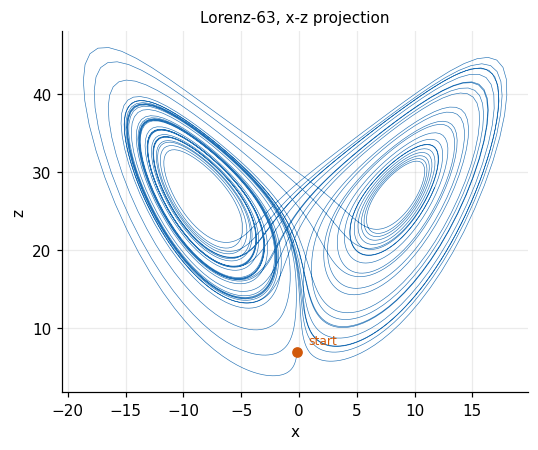

RK4 step Jacobian at the start point (from AD):
 [[ 9.14705373e-01  9.50134722e-02  7.28283850e-05]
 [ 2.00953359e-01  1.00024530e+00  1.52242035e-03]
 [-2.98950005e-03 -1.66932208e-03  9.73684504e-01]]


In [8]:
def rk4_step(s):
    k1 = rhs(s)
    k2 = rhs(s + 0.5 * DT * k1)
    k3 = rhs(s + 0.5 * DT * k2)
    k4 = rhs(s + DT * k3)
    return s + DT / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)


def trajectory(s, n):
    def body(c, _):
        c2 = rk4_step(c)
        return c2, c2
    return jax.lax.scan(body, s, None, length=n)[1]


warm = trajectory(s0, 2000)[-1]          # land on the attractor
orbit = np.asarray(trajectory(warm, 4000))

fig, ax = plt.subplots(figsize=(5.0, 4.2))
ax.plot(orbit[:, 0], orbit[:, 2], color=BLUE, lw=0.4)
ax.plot(float(warm[0]), float(warm[2]), "o", color=ORANGE, ms=6)
ax.annotate("start", (float(warm[0]) + 1.0, float(warm[2]) + 1.0), color=ORANGE, fontsize=8)
ax.set_xlabel("x"); ax.set_ylabel("z")
ax.set_title("Lorenz-63, x-z projection", fontsize=10)
fig.tight_layout()
plt.show()

print("RK4 step Jacobian at the start point (from AD):\n", np.asarray(jax.jacfwd(rk4_step)(warm)))

## 6. The chain rule is a matrix product — and that is all of AD

A model run is a composition. If $s_N = M_N \circ \dots \circ M_1(s_0)$ then the chain
rule says the Jacobian of the whole run is the **product of the step Jacobians**:

$$J_{\text{total}} = M_N\, M_{N-1} \cdots M_2\, M_1$$

each $M_k$ evaluated at the state the model actually passed through. In data
assimilation this product is the **tangent-linear model**, and its transpose is the
**adjoint model**. Check it against AD:

In [9]:
NSTEP = 200


def final_state(s):
    return trajectory(s, NSTEP)[-1]


visited = np.asarray(jnp.concatenate([warm[None], trajectory(warm, NSTEP)])[:-1])
step_jac = jax.jit(jax.jacfwd(rk4_step))

product = np.eye(3)
for st in visited:
    product = np.asarray(step_jac(jnp.asarray(st))) @ product

J_total = np.asarray(jax.jacfwd(final_state)(warm))
print("product of 200 step Jacobians:\n", product)
print("\nmax |product - jacfwd(whole run)| =", float(np.max(np.abs(product - J_total))))

product of 200 step Jacobians:
 [[ 3.11762547  2.8659723  -0.07645373]
 [-0.39577236 -0.36956268 -0.41553051]
 [ 8.10881365  7.46233371  0.39854069]]

max |product - jacfwd(whole run)| = 1.2434497875801753e-14


Now the observation that the entire subject rests on.

Matrix multiplication is **associative**, so that product can be evaluated in any
order — and the order changes the cost enormously. Two of the orders have names.

**Right to left, applied to a vector $v$.** Never form a matrix at all:

$$J v = M_N\big(M_{N-1}(\cdots(M_1 v))\big)$$

Each step is a matrix–vector product, done in lockstep with the forward run. This is
**forward mode**, a **Jacobian–vector product (JVP)**, the **tangent-linear model**.
It answers: *if I perturb the input in direction $v$, how does every output move?*

**Left to right, applied to a row vector $w^\top$.** Also never forms a matrix:

$$w^\top J = \big((w^\top M_N) M_{N-1}\big)\cdots M_1$$

Same product, opposite direction. This is **reverse mode**, a **vector–Jacobian
product (VJP)**, the **adjoint model**. It answers: *if I care about the output
combination $w$, how sensitive is it to every input?*

In [10]:
v = jnp.array([1.0, 0.0, 0.0])       # a perturbation direction
w = jnp.array([0.0, 1.0, 0.0])       # an output of interest

_, tangent = jax.jvp(final_state, (warm,), (v,))
_, vjp_fn = jax.vjp(final_state, warm)
(gradient,) = vjp_fn(w)

print("forward mode  J v   :", np.asarray(tangent))
print("matrix J @ v        :", J_total @ np.asarray(v))
print()
print("reverse mode  w^T J :", np.asarray(gradient))
print("matrix J.T @ w      :", J_total.T @ np.asarray(w))

forward mode  J v   : [ 3.11762547 -0.39577236  8.10881365]
matrix J @ v        : [ 3.11762547 -0.39577236  8.10881365]

reverse mode  w^T J : [-0.39577236 -0.36956268 -0.41553051]
matrix J.T @ w      : [-0.39577236 -0.36956268 -0.41553051]


Both agree with the explicit matrix, and neither built one.

That is worth restating, because it is the thing people miss: **AD never needs to form
the Jacobian.** It evaluates a product of Jacobians against a vector, in one of two
orders. (`jacfwd`/`jacrev` in section 9 do assemble one — by running $n$ or $m$ such
passes.) Everything else — tapes, dual numbers, checkpointing — is implementation
detail in service of those two orders.

## 7. Cost: why the adjoint exists

For $F:\mathbb{R}^n \to \mathbb{R}^m$, one forward pass gives one **column-direction**
($Jv$) and one reverse pass gives one **row-direction** ($w^\top J$). So

| | passes for a full Jacobian | cost per pass |
|---|---|---|
| forward mode | $n$ (one per input) | ~2–3× a function evaluation |
| reverse mode | $m$ (one per output) | ~3–4× a function evaluation |

Both are within a small constant of the original program **per pass**. The asymmetry
is entirely in how many passes you need.

For 4D-Var the cost function is a **scalar**: $m = 1$, $n \sim 10^7$. Reverse mode
delivers the whole gradient in *one* pass at a few times the cost of a forward model
run, independent of $n$. Forward mode would need $10^7$ passes, and finite differences
$10^7$ model runs. That factor of $10^7$ is why adjoint models exist, and why people
spent years hand-writing them before AD tools were trusted.

Measured on a function $\mathbb{R}^n \to \mathbb{R}$:

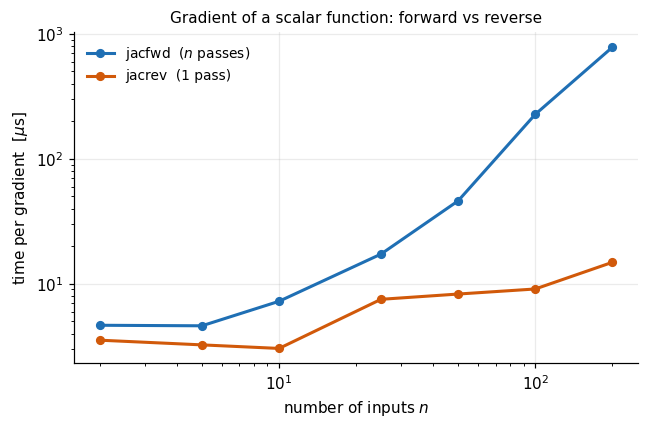

at n = 200: jacfwd    781.0 us, jacrev     14.9 us  -> reverse is ~53x cheaper here

These are CPU numbers and they are noisy at the tens-of-microseconds scale;
expect the ratio to move by tens of percent between runs. The trend is the point:
jacrev is flat in n, jacfwd is not.
jacrev monotone in n? True


In [11]:
def make_scalar_fn(n, seed=0):
    key = jax.random.PRNGKey(seed)
    Amat = jax.random.normal(key, (n, n)) / math.sqrt(n)
    def f(x):
        return jnp.sum(jnp.sin(Amat @ x) * jnp.cos(x))
    return f


def timeit(fn, x, repeat=300, batches=20):
    '''Min over batch means. More batches than you think: at microsecond scale the
    scheduler noise is comparable to the signal, and an under-sampled minimum can
    come out *below* the true cost and break monotonicity.'''
    for _ in range(5):
        fn(x).block_until_ready()                               # warm up / compile
    best = float("inf")
    for _ in range(batches):
        t = time.perf_counter()
        for _ in range(repeat):
            fn(x).block_until_ready()
        best = min(best, (time.perf_counter() - t) / repeat)
    return best


ns, t_fwd, t_rev = [2, 5, 10, 25, 50, 100, 200], [], []
for n in ns:
    f = make_scalar_fn(n)
    x = jnp.asarray(np.random.default_rng(0).standard_normal(n))
    t_fwd.append(timeit(jax.jit(jax.jacfwd(f)), x))
    t_rev.append(timeit(jax.jit(jax.jacrev(f)), x))

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.loglog(ns, np.array(t_fwd) * 1e6, "o-", color=BLUE, lw=2, ms=5, label="jacfwd  ($n$ passes)")
ax.loglog(ns, np.array(t_rev) * 1e6, "o-", color=ORANGE, lw=2, ms=5, label="jacrev  (1 pass)")
ax.set_xlabel("number of inputs $n$")
ax.set_ylabel("time per gradient  [$\\mu$s]")
ax.set_title("Gradient of a scalar function: forward vs reverse", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

print(f"at n = {ns[-1]}: jacfwd {t_fwd[-1]*1e6:8.1f} us, jacrev {t_rev[-1]*1e6:8.1f} us"
      f"  -> reverse is ~{t_fwd[-1]/t_rev[-1]:.0f}x cheaper here")
print("\nThese are CPU numbers and they are noisy at the tens-of-microseconds scale;")
print("expect the ratio to move by tens of percent between runs. The trend is the point:")
print("jacrev is flat in n, jacfwd is not.")
print(f"jacrev monotone in n? {all(a <= b * 1.25 for a, b in zip(t_rev, t_rev[1:]))}")

The gap widens with `n`, exactly as the table says. At tiny `n` the two are comparable
and dominated by dispatch overhead — reverse mode is not magic, it is a better
*ordering*.

Treat the absolute microsecond figures with suspicion. At this scale the measurement
is scheduler-noise-limited and the ratio moves substantially between runs; on a GPU
both curves flatten into launch latency and the comparison says nothing at all. What
is robust is the *shape*: `jacrev` roughly flat in $n$, `jacfwd` rising with it.

## 8. Reverse mode from scratch: the tape

Forward mode was easy because derivative information flows the same way the program
does: one extra component per value, carried along.

Reverse mode flows **backwards**, and that is the whole difficulty. You cannot know
$\partial(\text{output})/\partial(\text{this intermediate})$ until you have seen every
later use of that intermediate. So the algorithm is necessarily two passes:

1. **Forward pass** — run the program, and record every elementary operation together
   with its local partial derivatives. That record is the **tape**.
2. **Backward pass** — walk the tape in reverse, seeding the output with cotangent 1,
   and accumulate $\bar{u} \mathrel{+}= \bar{v}\,\partial v/\partial u$ for each recorded edge.

The `+=` is essential: a value used in three places collects three contributions. This
is the same accumulation that appears in `nb01` when the halo cotangent comes home.

In [12]:
class Tape:
    def __init__(self):
        self.ops = []           # (output_node, ((input_node, local_partial), ...))


class Var:
    def __init__(self, value, tape):
        self.v, self.tape = value, tape

    def _lift(self, o):
        return o if isinstance(o, Var) else Var(o, self.tape)

    def _record(self, value, edges):
        out = Var(value, self.tape)
        self.tape.ops.append((out, edges))
        return out

    def __add__(self, o):
        o = self._lift(o)
        return self._record(self.v + o.v, ((self, 1.0), (o, 1.0)))

    def __mul__(self, o):
        o = self._lift(o)
        return self._record(self.v * o.v, ((self, o.v), (o, self.v)))

    def __truediv__(self, o):
        o = self._lift(o)
        return self._record(self.v / o.v, ((self, 1.0 / o.v), (o, -self.v / o.v**2)))

    def __sub__(self, o):
        o = self._lift(o)
        return self._record(self.v - o.v, ((self, 1.0), (o, -1.0)))

    __radd__ = __add__
    __rmul__ = __mul__

    def __rsub__(self, o):
        return self._lift(o) - self

    def __rtruediv__(self, o):
        return self._lift(o) / self

    def __neg__(self):
        return self._record(-self.v, ((self, -1.0),))

    def exp(self):
        e = math.exp(self.v)
        return self._record(e, ((self, e),))


def backward(tape, output):
    '''Walk the tape in reverse, accumulating cotangents.'''
    bar = defaultdict(float)
    bar[output] = 1.0
    for node, edges in reversed(tape.ops):
        g = bar[node]
        if g == 0.0:
            continue
        for parent, local in edges:
            bar[parent] += g * local          # the accumulation
    return bar


tape = Tape()
T = Var(T0, tape)
result = es_generic(T, lambda u: u.exp())     # the same unmodified function
bar = backward(tape, result)

print(f"value      : {result.v:.15f}")
print(f"derivative : {bar[T]:.15f}")
print(f"exact      : {exact:.15f}")
print(f"error      : {abs(bar[T] - exact):.2e}")
print(f"\ntape length: {len(tape.ops)} operations")

value      : 1701.982814715586755
derivative : 109.493411247247650
exact      : 109.493411247247650
error      : 0.00e+00

tape length: 5 operations


Exact again, and `es_generic` still has not changed — it has now been run in three
different arithmetics.

That example does not actually test the claim this section makes, though. Every
intermediate in the Tetens formula is consumed exactly once, so each `bar[parent]` is
written a single time and the `+=` never accumulates anything. The case that breaks
naive tape implementations is a value used more than once:

In [13]:
def reuse(T, exp):
    # every intermediate below is consumed more than once
    u = exp(T / 50.0)
    return (u + T) * (u - T) / u


tape = Tape()
T = Var(T0, tape)
bar = backward(tape, reuse(T, lambda x: x.exp()))

central = (reuse(T0 + 1e-6, math.exp) - reuse(T0 - 1e-6, math.exp)) / 2e-6
print(f"tape derivative    : {bar[T]:.12f}")
print(f"jax.grad           : {float(jax.grad(lambda x: reuse(x, jnp.exp))(T0)):.12f}")
print(f"central difference : {central:.12f}")
print(f"\ntape length: {len(tape.ops)} operations")

tape derivative    : -18.863867451232
jax.grad           : -18.863867451232
central difference : -18.863867424557

tape length: 6 operations


Agreement to roundoff, and now the `+=` is load-bearing: `u` feeds three separate
operations, so `bar[u]` is a sum of three contributions. Replace `+=` with `=` and this
example breaks while the Tetens one keeps passing — which is exactly the kind of bug a
too-simple test waves through. (Note this also needed `__sub__`, which the class above
provides; the Tetens formula never subtracts.)

The tape is also where reverse mode's cost lives. It grows with the **number of
operations executed**, so differentiating a long time integration stores every
intermediate of every step. That is the memory wall every adjoint model hits, and the
standard answer is **checkpointing**: keep states only at intervals and recompute the
rest during the backward pass, trading time for memory. Section 11 shows JAX's version.

## 9. What JAX gives you, and the NWP dictionary

Everything above exists in JAX, implemented on traced computation graphs rather than
Python objects, and composable with `jit`, `vmap`, and each other.

| what you want | JAX | AD term | weather/climate term |
|---|---|---|---|
| $Jv$, one direction in | `jax.jvp` | forward mode, JVP | tangent-linear model (TLM) |
| $w^\top J$, one direction out | `jax.vjp` | reverse mode, VJP | adjoint model |
| $\nabla f$ for scalar $f$ | `jax.grad` | reverse mode | adjoint / gradient |
| full $J$, few inputs | `jax.jacfwd` | $n$ JVPs, vectorised | — |
| full $J$, few outputs | `jax.jacrev` | $m$ VJPs, vectorised | — |
| value and gradient together | `jax.value_and_grad` | | |

The two vocabularies grew up independently. Reverse-mode AD was already in the
numerical-computing literature — Linnainmaa (1970, 1976), and Speelpenning's thesis
(1980) for the first automatic implementation — when the adjoint arrived in
atmospheric science, first as sensitivity analysis (Marchuk 1974; Hall, Cacuci &
Schlesinger 1982) and then industrialised by variational data assimilation
(Le Dimet & Talagrand 1986; Talagrand & Courtier 1987). Same computation, two names,
neither borrowed from the other.

One caveat before treating the words as synonyms. Reverse-mode AD gives the
**discrete** adjoint — the exact transpose of the code as written. The **continuous**
adjoint, derived from the PDE and then discretised, is a different operator, and
operational adjoint models are deliberately neither (see section 11).

In [14]:
def cost(s):
    '''A scalar functional of the trajectory -- stands in for a 4D-Var cost.'''
    traj = trajectory(s, NSTEP)
    target = jnp.array([0.0, 0.0, 25.0])
    return 0.5 * jnp.sum((traj[-1] - target) ** 2)


value, grad = jax.value_and_grad(cost)(warm)
print(f"cost      = {float(value):.8f}")
print(f"gradient  = {np.asarray(grad)}")
print(f"jacfwd row= {np.asarray(jax.jacfwd(cost)(warm))}   "
      f"(same thing, {warm.size} passes instead of 1)")

cost      = 29.50164725
gradient  = [21.65234011 19.88186153 -2.21451254]
jacfwd row= [21.65234011 19.88186153 -2.21451254]   (same thing, 3 passes instead of 1)


## 10. Verifying a gradient: the two tests

Never trust a gradient you have not tested. Two tests carry most of the load; between
them they catch the great majority of adjoint bugs.

### The Taylor test — for the gradient of a nonlinear functional

From Taylor's theorem, with $d$ a random direction:

$$r_1(h) = |\mathcal{J}(x + hd) - \mathcal{J}(x)| = O(h)$$
$$r_2(h) = |\mathcal{J}(x + hd) - \mathcal{J}(x) - h\,\langle \nabla \mathcal{J}, d\rangle| = O(h^2)$$

$r_1$ confirms only that $\mathcal{J}$ is Lipschitz along $d$ — it says nothing about the
gradient. **$r_2$ converging at second order is what confirms the gradient.** Halve
`h`, and $r_2$ should quarter. If it decays at first order, the gradient is wrong.

(The cost functional is written $\mathcal{J}$ here to keep it distinct from the Jacobian
$J$ of the previous sections.)

         h            r1            r2   rate1   rate2
  1.00e-02   1.32069e-02   1.66941e-05     nan     nan
  5.00e-03   6.60763e-03   4.17446e-06    1.00    2.00
  2.50e-03   3.30486e-03   1.04373e-06    1.00    2.00


  1.25e-03   1.65269e-03   2.60948e-07    1.00    2.00
  6.25e-04   8.26410e-04   6.52388e-08    1.00    2.00
  3.13e-04   4.13222e-04   1.63099e-08    1.00    2.00
  1.56e-04   2.06615e-04   4.07742e-09    1.00    2.00
  7.81e-05   1.03308e-04   1.01934e-09    1.00    2.00


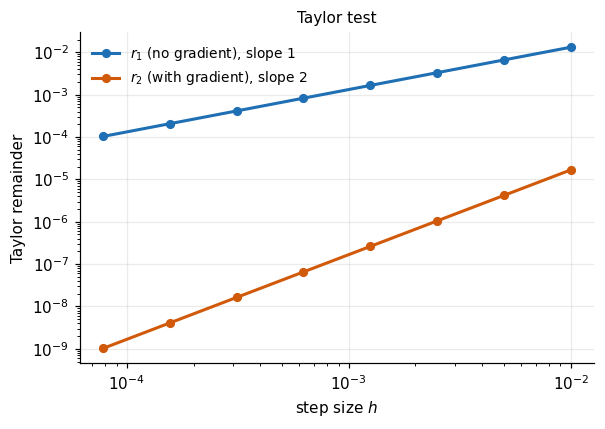

In [15]:
rng = np.random.default_rng(0)
d = jnp.asarray(rng.standard_normal(3))
J0 = float(cost(warm))
dirderiv = float(jnp.sum(grad * d))

print(f"{'h':>10} {'r1':>13} {'r2':>13} {'rate1':>7} {'rate2':>7}")
hs_t, r1s, r2s = [], [], []
h, p1, p2 = 1e-2, None, None
for _ in range(8):
    Jh = float(cost(warm + h * d))
    r1, r2 = abs(Jh - J0), abs(Jh - J0 - h * dirderiv)
    s1 = math.log2(p1 / r1) if p1 else float("nan")
    s2 = math.log2(p2 / r2) if p2 else float("nan")
    print(f"{h:10.2e} {r1:13.5e} {r2:13.5e} {s1:7.2f} {s2:7.2f}")
    hs_t.append(h); r1s.append(r1); r2s.append(r2)
    p1, p2, h = r1, r2, h / 2

fig, ax = plt.subplots(figsize=(5.6, 4.0))
ha = np.array(hs_t)
ax.loglog(ha, r1s, "o-", color=BLUE, lw=2, ms=5, label="$r_1$ (no gradient), slope 1")
ax.loglog(ha, r2s, "o-", color=ORANGE, lw=2, ms=5, label="$r_2$ (with gradient), slope 2")
ax.set_xlabel("step size $h$"); ax.set_ylabel("Taylor remainder")
ax.set_title("Taylor test", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

### The dot-product test — for a tangent-linear / adjoint pair

If the TLM and adjoint are genuinely transposes of one another then for **any** $v$
and $w$:

$$\langle J v,\, w \rangle = \langle v,\, J^\top w \rangle$$

This is an identity, not an approximation, so it must hold to machine roundoff. It is
the standard acceptance test for a hand-written adjoint, and it is what `nb01` uses on
the halo exchange.

In [16]:
dp_rng = np.random.default_rng(7)                    # local seed: cell is self-contained
v = jnp.asarray(dp_rng.standard_normal(3))
w = jnp.asarray(dp_rng.standard_normal(3))

_, Jv = jax.jvp(final_state, (warm,), (v,))
_, vjp_fn = jax.vjp(final_state, warm)
(JTw,) = vjp_fn(w)

lhs, rhs_ = float(jnp.sum(Jv * w)), float(jnp.sum(v * JTw))
print(f"<J v, w>    = {lhs:.16e}")
print(f"<v, J^T w>  = {rhs_:.16e}")
print(f"relative    = {abs(lhs - rhs_) / abs(lhs):.2e}")

<J v, w>    = -2.8982418419185589e+00
<v, J^T w>  = -2.8982418419185598e+00
relative    = 3.06e-16


## 11. Where it gets hard

AD is exact and mechanical, which makes it easy to over-trust. Three things bite.

### Kinks

`max`, `abs`, `min`, `where`, and every limiter and threshold in a physics
parameterisation are not differentiable everywhere. AD does not warn you at these
points. It returns a number — and *which* number depends on how the code happens to be
spelled.

Below is the same mathematical function, ReLU, written four ways. All four agree at
**every** input, $x = 0$ included — as the value columns below show. What differs is
the derivative AD reports at the kink.

In [17]:
spellings = {
    "maximum(x, 0)":       lambda x: jnp.maximum(x, 0.0),
    "where(x > 0, x, 0)":  lambda x: jnp.where(x > 0, x, 0.0),
    "where(x >= 0, x, 0)": lambda x: jnp.where(x >= 0, x, 0.0),
    "0.5 * (x + abs(x))":  lambda x: 0.5 * (x + jnp.abs(x)),
}

print(f"{'spelling':>22} | {'f(-1)':>6} {'f(0)':>5} {'f(1)':>5} | {'AD derivative at x=0':>21}")
print("-" * 74)
for name, f in spellings.items():
    vals = [float(f(t)) for t in (-1.0, 0.0, 1.0)]
    print(f"{name:>22} | {vals[0]:6.1f} {vals[1]:5.1f} {vals[2]:5.1f} | {float(jax.grad(f)(0.0)):21.1f}")

h = 1e-3
relu = spellings["maximum(x, 0)"]
print(f"\ncentral difference across the kink (h={h}): "
      f"{(float(relu(h)) - float(relu(-h))) / (2 * h)}")

              spelling |  f(-1)  f(0)  f(1) |  AD derivative at x=0
--------------------------------------------------------------------------
         maximum(x, 0) |    0.0   0.0   1.0 |                   0.5
    where(x > 0, x, 0) |    0.0   0.0   1.0 |                   0.0
   where(x >= 0, x, 0) |    0.0   0.0   1.0 |                   1.0
    0.5 * (x + abs(x)) |    0.0   0.0   1.0 |                   1.0

central difference across the kink (h=0.001): 0.5


Four spellings of one function, three different derivatives at the kink. None is
wrong: the derivative does not exist there, the subdifferential is the whole interval
$[0, 1]$, and each spelling selects some element of it — two of them happen to pick the
same one. What matters is that **the number you get is a property of the source code,
not of the mathematics**, and nothing about testing the forward model will reveal which
one you have.

It is tempting to assume the exact tie never arises in floating point. In atmospheric
codes it arises constantly: `max(q, 0.0)` applied to a field a previous limiter has
already clipped to exactly zero hits the tie at every clipped point, and that pattern
is everywhere in microphysics and tracer transport.

The subtler damage is done *near* the kink, where the derivative is a step function of
the input: the tangent-linear approximation is valid on one side of the threshold and
wrong on the other, however small the perturbation. A Taylor test straddling such a
switch will refuse to reach second order, and the cause is usually the physics, not a
bug in the adjoint.

This is why operational TL/adjoint models deliberately *smooth* or *linearise around*
switches — the adjoint physics is intentionally not the exact derivative of the
nonlinear code.

### What operational models actually do about it

ECMWF calls the fix **regularization**: *"to smooth the parametrized discontinuities in
order to make the scheme as much differentiable as possible"* (Tech. Memo. 666, §3.2).
The same document names three distinct kinds of trouble — discontinuous functions and
on/off processes (saturation, phase change); continuous functions whose *derivative*
blows up; and strong non-linearities such as the stable↔unstable boundary-layer
transition.

What is striking, reading what they actually did, is that "replace `max` with a smooth
function" is only one of three techniques, and not the most common:

1. **Flatten the function.** The Sundqvist autoconversion curve is made less steep so
   the TL increment shrinks toward the nonlinear one. This changes the physics, and the
   memo is explicit that it "can deteriorate the overall quality of the physical
   parametrization itself".
2. **Freeze the perturbation.** In vertical diffusion, *"perturbations of the exchange
   coefficients were simply neglected ($K' = 0$)"* (Mahfouf 1999) — the derivative of
   the offending term is set to zero and the trajectory value is kept.
3. **Damp the perturbation near the trouble.** The later vertical-diffusion scheme
   reduces perturbations *"around the neutral state (i.e. Ri close to zero) where both
   the function of Ri itself and its derivative exhibit a significant rate of change.
   The reduction is eased exponentially away from the neutral state."* The convection
   scheme likewise reduces or zeroes perturbations of terms depending on updraught
   velocity.

Techniques 2 and 3 modify **only the derivative**. The nonlinear forecast model is left
alone; just its linearization is altered. That is worth stating plainly: **the
operational tangent-linear model is deliberately not the derivative of the operational
nonlinear model.**

### Smooth surrogates for `max(x, 0)`

When you do want to smooth the function, three surrogates cover almost all use:

$$\text{softplus}_\beta(x) = \tfrac{1}{\beta}\log\!\left(1 + e^{\beta x}\right),
\qquad
\tfrac{1}{2}\!\left(x + \sqrt{x^2 + \varepsilon^2}\right),
\qquad
x\,\Phi\!\left(\tfrac{x}{\varepsilon}\right) + \varepsilon\,\phi\!\left(\tfrac{x}{\varepsilon}\right)$$

with $\Phi$, $\phi$ the standard normal CDF and PDF. All three converge to $\max(x,0)$
as $\beta \to \infty$ or $\varepsilon \to 0$.

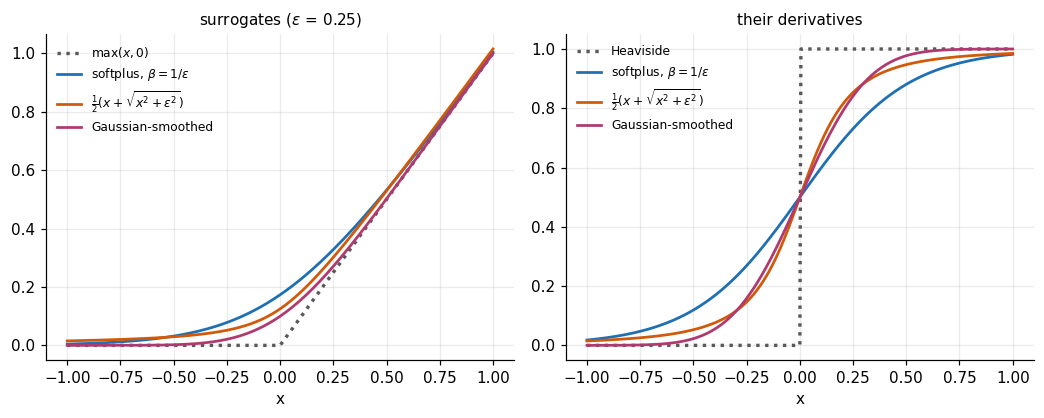

In [18]:
from jax.scipy.stats import norm

EPS = 0.25


def softplus_b(x, beta):
    return jax.nn.softplus(beta * x) / beta


def sqrt_smooth(x, eps):
    return 0.5 * (x + jnp.sqrt(x**2 + eps**2))


def gauss_smooth(x, eps):
    return x * norm.cdf(x / eps) + eps * norm.pdf(x / eps)


xg = jnp.linspace(-1.0, 1.0, 401)
curves = [("softplus, $\\beta=1/\\varepsilon$", lambda z: softplus_b(z, 1 / EPS), BLUE),
          ("$\\frac{1}{2}(x+\\sqrt{x^2+\\varepsilon^2})$", lambda z: sqrt_smooth(z, EPS), ORANGE),
          ("Gaussian-smoothed", lambda z: gauss_smooth(z, EPS), MAGENTA)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.9))
ax1.plot(xg, jnp.maximum(xg, 0.0), color="0.35", lw=2.2, ls=":", label="$\\max(x,0)$")
ax2.plot(xg, (xg > 0).astype(float), color="0.35", lw=2.2, ls=":", label="Heaviside")
for lbl, f, col in curves:
    ax1.plot(xg, f(xg), color=col, lw=1.8, label=lbl)
    ax2.plot(xg, jax.vmap(jax.grad(f))(xg), color=col, lw=1.8, label=lbl)
ax1.set_title(f"surrogates ($\\varepsilon$ = {EPS})", fontsize=10)
ax2.set_title("their derivatives", fontsize=10)
for ax in (ax1, ax2):
    ax.set_xlabel("x")
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The third is not an arbitrary choice. It is *exactly* the grid-box mean of `max` when
the input has unresolved sub-grid variability:

$$\mathbb{E}_{\xi\sim N(0,1)}\big[\max(x + \varepsilon\xi,\,0)\big]
= x\,\Phi(x/\varepsilon) + \varepsilon\,\phi(x/\varepsilon),
\qquad\text{so}\qquad
\frac{d}{dx}\mathbb{E}[\cdot] = \Phi(x/\varepsilon).$$

So the smoothed Heaviside is the honest derivative of the *grid-box-mean* model rather
than a fudge — the same argument statistical cloud schemes make when they replace the
saturation switch by an assumed sub-grid humidity distribution (Sommeria & Deardorff
1977; Mellor 1977).

In [19]:
key = jax.random.PRNGKey(0)
xi = jax.random.normal(key, (400_000,))
probe = jnp.linspace(-1.0, 1.0, 9)

mc = jnp.array([jnp.mean(jnp.maximum(x + EPS * xi, 0.0)) for x in probe])
print(f"E[max(x+eps*xi,0)]: Monte Carlo vs closed form, max diff = "
      f"{float(jnp.max(jnp.abs(mc - gauss_smooth(probe, EPS)))):.2e}")

dsmooth = jax.vmap(jax.grad(lambda z: gauss_smooth(z, EPS)))(probe)
print(f"d/dx of it vs Phi(x/eps),                    max diff = "
      f"{float(jnp.max(jnp.abs(dsmooth - norm.cdf(probe / EPS)))):.2e}")

E[max(x+eps*xi,0)]: Monte Carlo vs closed form, max diff = 6.74e-04


d/dx of it vs Phi(x/eps),                    max diff = 1.11e-16


### Doing it the operational way in JAX: `jax.custom_jvp`

Techniques 2 and 3 above need something specific: keep the nonlinear code **exactly as
it is**, and replace only its linearization. That is precisely what `jax.custom_jvp`
provides — you supply the tangent rule and JAX keeps your primal.

In [20]:
@jax.custom_jvp
def relu_regularized(x):
    return jnp.maximum(x, 0.0)          # the nonlinear model, untouched


@relu_regularized.defjvp
def _relu_regularized_jvp(primals, tangents):
    (x,), (dx,) = primals, tangents
    return relu_regularized(x), norm.cdf(x / EPS) * dx      # the regularized tangent


probe2 = jnp.linspace(-1.0, 1.0, 11)
print("forward values identical to jnp.maximum:",
      bool(jnp.allclose(relu_regularized(probe2), jnp.maximum(probe2, 0.0))))
print(f"derivative at x = -0.5 : {float(jax.grad(relu_regularized)(-0.5)):.4f}")
print(f"derivative at x =  0.0 : {float(jax.grad(relu_regularized)(0.0)):.4f}")
print(f"derivative at x = +0.5 : {float(jax.grad(relu_regularized)(0.5)):.4f}")

forward values identical to jnp.maximum: True


derivative at x = -0.5 : 0.0228
derivative at x =  0.0 : 0.5000
derivative at x = +0.5 : 0.9772


`custom_jvp` is enough for both modes here: the tangent rule is linear in `dx`, so JAX
transposes it automatically to get the adjoint. Reach for `custom_vjp` only when the
backward pass needs something the forward cannot express — which is exactly the case in
`nb02`, where the backward pass has to run an MPI exchange in the opposite direction.

### The price, measured

Regularization is not free, and the Taylor test is where you pay. Below: a functional
$\sum_i \max(x_i, 0)$ with twenty of the $x_i$ sitting *exactly* on the switch.

In [21]:
kink_rng = np.random.default_rng(0)
xk = kink_rng.standard_normal(200) * 0.3
xk[:20] = 0.0                                     # points sitting exactly on the switch
xk = jnp.asarray(xk)
dk = jnp.asarray(kink_rng.standard_normal(200))

print(f"{'variant':>26} | {'r2 convergence rate':>32}")
print("-" * 62)
for name, fn in [("exact max(x, 0)", lambda z: jnp.sum(jnp.maximum(z, 0.0))),
                 ("smoothed function", lambda z: jnp.sum(gauss_smooth(z, EPS))),
                 ("custom_jvp (regularized TL)", lambda z: jnp.sum(relu_regularized(z)))]:
    Jk = float(fn(xk))
    slope = float(jnp.sum(jax.grad(fn)(xk) * dk))
    rates, hh, prev = [], 1e-2, None
    for _ in range(6):
        r2 = abs(float(fn(xk + hh * dk)) - Jk - hh * slope)
        if prev:
            rates.append(math.log2(prev / r2))
        prev, hh = r2, hh / 2
    print(f"{name:>26} | {'  '.join(f'{r:5.2f}' for r in rates)}")

                   variant |              r2 convergence rate
--------------------------------------------------------------


           exact max(x, 0) |  1.07   1.14   1.10   1.00   1.00


         smoothed function |  2.00   2.00   2.00   2.00   2.00
custom_jvp (regularized TL) |  1.07   1.16   1.11   1.00   1.00


Read that table carefully, because it contains the whole trade.

**Smoothing the function** restores genuine differentiability, and the Taylor test
returns to second order. You have changed the model, and the gradient is the true
gradient of the model you now have.

**Smoothing only the derivative** — the `custom_jvp` route, and what operational
centres do — leaves the Taylor test stuck at first order, exactly as the raw kink does.
That is not a bug. The gradient is deliberately not $\nabla \mathcal{J}$, so the
second-order term it is supposed to cancel does not cancel. What you buy is a
linearization that stays *stable and useful at the finite perturbation amplitudes
4D-Var actually uses*, instead of one that is pointwise exact and numerically violent.
ECMWF's own before/after comparison is the argument: without regularization the TL
increments develop spurious noise that the nonlinear finite differences do not show;
with it, they agree.

The practical lesson for anyone validating an adjoint: **before hunting for a bug in a
Taylor test stuck at first order, check whether someone regularized the linearization
on purpose.**

### Memory

The tape grows with the operation count. `jax.checkpoint` (`jax.remat`) discards the
intermediates of a block and recomputes them during the backward pass. Same gradient,
less memory, more arithmetic — and the memory claim is worth measuring rather than
asserting, so the cell below reads the compiled temporary-buffer size out of XLA.

In [22]:
def rollout(s, n, step):
    return jax.lax.scan(lambda c, _: (step(c), None), s, None, length=n)[0]


plain = jax.jit(jax.grad(lambda s: jnp.sum(rollout(s, 500, rk4_step) ** 2)))
remat = jax.jit(jax.grad(lambda s: jnp.sum(rollout(s, 500, jax.checkpoint(rk4_step)) ** 2)))

g1, g2 = plain(warm), remat(warm)
print("gradient without checkpointing:", np.asarray(g1))
print("gradient with    checkpointing:", np.asarray(g2))
print("max difference:", float(jnp.max(jnp.abs(g1 - g2))))


def peak_temp_bytes(fn, x):
    return fn.lower(x).compile().memory_analysis().temp_size_in_bytes


print(f"\ntemporaries without checkpointing: {peak_temp_bytes(plain, warm):>9,d} bytes")
print(f"temporaries with    checkpointing: {peak_temp_bytes(remat, warm):>9,d} bytes")

gradient without checkpointing: [-335.11038274 -307.76541389   30.0863175 ]
gradient with    checkpointing: [-335.11038274 -307.76541389   30.0863175 ]
max difference: 0.0

temporaries without checkpointing:    49,288 bytes
temporaries with    checkpointing:    12,872 bytes


### Chaos

This one is physics, not software. In a chaotic system the tangent-linear model grows
like $e^{\lambda t}$ with $\lambda$ the leading Lyapunov exponent. The gradient stays
*correct* — it is the true derivative of the model — but it stops being *useful*,
because the linearisation is only valid over a shrinking neighbourhood.

Measure $\lambda$ for Lorenz-63 by propagating a tangent vector with `jax.jvp` and
renormalising:

In [23]:
@functools.partial(jax.jit, static_argnums=2)
def lyapunov(s, v, n):
    def body(carry, _):
        s, v, acc = carry
        s2, v2 = jax.jvp(rk4_step, (s,), (v,))
        nrm = jnp.linalg.norm(v2)
        return (s2, v2 / nrm, acc + jnp.log(nrm)), None
    (_, _, acc), _ = jax.lax.scan(body, (s, v, 0.0), None, length=n)
    return acc / (n * DT)


for n in (5_000, 50_000, 200_000):
    lam = float(lyapunov(warm, jnp.array([1.0, 0.0, 0.0]), n))
    print(f"averaged over t = {n * DT:7.1f} :  lambda = {lam:.4f}")
print("published value for Lorenz-63: 0.906")

averaged over t =    50.0 :  lambda = 0.8319
averaged over t =   500.0 :  lambda = 0.8813


averaged over t =  2000.0 :  lambda = 0.9000
published value for Lorenz-63: 0.906


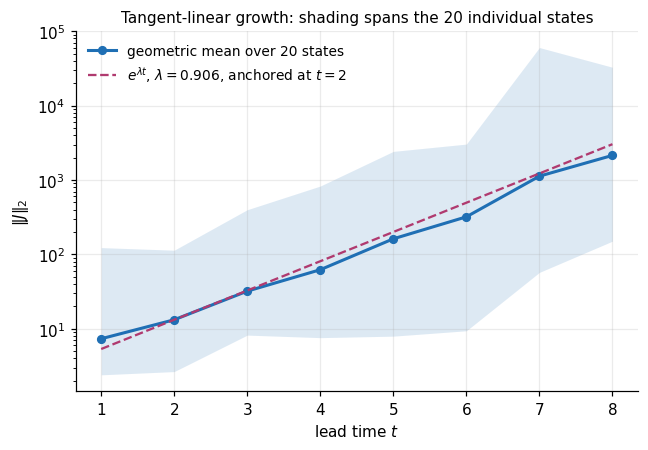

In [24]:
starts = np.asarray(trajectory(warm, 4000))[::200][:20]
lead, geo, lo, hi = [], [], [], []
for n in (100, 200, 300, 400, 500, 600, 700, 800):      # evenly spaced t = 1..8
    f = jax.jit(jax.jacfwd(lambda s: trajectory(s, n)[-1]))
    nrms = np.array([float(jnp.linalg.norm(f(jnp.asarray(s)), 2)) for s in starts])
    lead.append(n * DT); geo.append(np.exp(np.mean(np.log(nrms))))
    lo.append(nrms.min()); hi.append(nrms.max())

fig, ax = plt.subplots(figsize=(6.0, 4.2))
ax.fill_between(lead, lo, hi, color=BLUE, alpha=0.15, lw=0)
anchor = 1                                    # t = 2, past the initial alignment transient
ax.semilogy(lead, geo, "o-", color=BLUE, lw=2, ms=5, label="geometric mean over 20 states")
ax.semilogy(lead, geo[anchor] * np.exp(0.906 * (np.array(lead) - lead[anchor])), "--",
            color=MAGENTA, lw=1.5, label="$e^{\\lambda t}$, $\\lambda = 0.906$, anchored at $t=2$")
ax.set_xlabel("lead time $t$"); ax.set_ylabel("$\\|J\\|_2$")
ax.set_title("Tangent-linear growth: shading spans the 20 individual states", fontsize=10)
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

Two things to take from that figure. The average grows exponentially at roughly the
Lyapunov rate — after 8 time units a unit perturbation is amplified by $\sim10^3$. The
gradient remains exactly correct in float64; what degrades is its *usefulness*. The
linear approximation it encodes is valid only over a shrinking neighbourhood, and the
Hessian becomes badly conditioned, so the minimisation is dominated by a handful of
fast-growing directions. Those directions are physically real — they are the leading
singular vectors — not numerical noise.

Lorenz-63 time is non-dimensional, so none of this converts directly into hours. But
the same mechanism, at atmospheric growth rates, is one of the reasons operational
4D-Var uses assimilation windows of 6–12 hours rather than days — alongside forecast
cycle timeliness and observation availability.

And the shaded band spans two orders of magnitude *at the same lead time*. Sensitivity
is strongly flow-dependent; there is no single "predictability horizon", which is the
entire motivation for flow-dependent background error covariances.

## 12. From three variables to a model

Everything here was three variables. A weather model has $10^7$–$10^9$, and three
things change:

- **The Jacobian is unthinkable as a matrix.** At $10^7$ states it has $10^{14}$
  entries. It was never going to be formed, which is why sections 6 and 7 insisted the
  product is only ever applied to a vector.
- **The state is a set of fields on a grid**, so the elementary operations are not
  `+` and `exp` but *stencils* — and a stencil's derivative is mostly about **where
  data moves**, not what arithmetic is done to it. The transpose of "gather from the
  neighbour" is "scatter to the neighbour, and accumulate".
- **The model is distributed**, so some of that data movement is MPI. The adjoint of a
  halo exchange runs the communication backwards and turns assignment into
  accumulation.

Those last two points are the subject of the rest of the series:

- **`nb01_halo_exchange_adjoint.ipynb`** — the adjoint of a halo exchange in GT4Py's
  field view, derived, hand-written in the DSL, and the two ways to get it wrong.
- **`nb02_distributed_ad.ipynb`** — the same across processes, via `shard_map` +
  `ppermute` and via MPI + `custom_vjp`.

The two verification tests from section 10 are used throughout both.

---

### References

**Automatic differentiation**

- Griewank & Walther, *Evaluating Derivatives*, 2nd ed., SIAM 2008 — the standard reference.
- Baydin, Pearlmutter, Radul & Siskind, *Automatic differentiation in machine learning: a survey*, JMLR **18**(153), 2018.
- Linnainmaa, *Taylor expansion of the accumulated rounding error*, BIT **16**, 146–160, 1976 — the reverse mode, before it had the name.
- Speelpenning, *Compiling fast partial derivatives of functions given by algorithms*, PhD thesis, Univ. Illinois, 1980.
- JAX autodiff cookbook: https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html

**Adjoints in weather and climate**

- Janisková & Lopez, *Linearized physics for data assimilation at ECMWF*, ECMWF Tech. Memo. 666, 2012 — sections 3.2 and 5.1 are the source for the regularization techniques in section 11.
- Mahfouf, *Influence of physical processes on the tangent-linear approximation*, Tellus A **51**, 147–166, 1999 — the $K'=0$ vertical-diffusion result.
- Zou, *Tangent linear and adjoint of "on-off" processes and their feasibility for use in 4-dimensional variational data assimilation*, Tellus A **49**(1), 1997.
- Tompkins & Janisková, *A cloud scheme for data assimilation*, Q. J. R. Meteorol. Soc. **130**, 2495–2517, 2004.
- Sommeria & Deardorff, *Subgrid-scale condensation in models of nonprecipitating clouds*, J. Atmos. Sci. **34**, 344–355, 1977; Mellor, *The Gaussian cloud model relations*, J. Atmos. Sci. **34**, 356–358, 1977 — the sub-grid-PDF argument behind the Gaussian-smoothed switch.

- Errico, *What is an adjoint model?*, Bull. Amer. Meteor. Soc. **78**(11), 2577–2591, 1997 — written for exactly this audience.
- Hall, Cacuci & Schlesinger, *Sensitivity analysis of a radiative–convective model by the adjoint method*, J. Atmos. Sci. **39**, 2038–2050, 1982.
- Le Dimet & Talagrand, *Variational algorithms for analysis and assimilation of meteorological observations: theoretical aspects*, Tellus A **38**(2), 97–110, 1986.
- Talagrand & Courtier, *Variational assimilation of meteorological observations with the adjoint vorticity equation. I: Theory*, Q. J. R. Meteorol. Soc. **113**, 1311–1328, 1987.

**Numerics used above**

- Squire & Trapp, *Using complex variables to estimate derivatives of real functions*, SIAM Review **40**(1), 110–112, 1998 — the complex-step trick.
- Martins, Sturdza & Alonso, *The complex-step derivative approximation*, ACM TOMS **29**(3), 245–262, 2003 — how to make it survive `abs`/`max`.
- Alduchov & Eskridge, *Improved Magnus form approximation of saturation vapor pressure*, J. Appl. Meteor. **35**, 601–609, 1996 — the coefficients used in section 1.